In [1]:
import numpy as np
import networkx as nx
import pandas as pd
import matplotlib.pyplot as plt

import h5py

In [33]:
path = '/n/holystore01/LABS/iaifi_lab/Lab/nswood/toy_tree_test_dataset/train/train_1.h5'

with h5py.File(path, 'r') as f:
    datasets = f['datasets'][:]
    labels = f['labels'][:]

In [2]:
def generate_regular_tree(d, depth):
    G = nx.Graph()
    node_counter = 0

    def add_node(parent, current_depth):
        nonlocal node_counter
        current_node = node_counter
        node_counter += 1
        G.add_node(current_node)
        if parent is not None:
            G.add_edge(parent, current_node)
        if current_depth < depth:
            # The root gets d children; every other node gets d-1 children.
            children_count = d if parent is None else d - 1
            for _ in range(children_count):
                add_node(current_node, current_depth + 1)

    add_node(parent=None, current_depth=0)
    return G

In [17]:
def gen_sampled_tree(d, depth, k_perturb=0.1, depth_perturb=0.1):
    G = generate_regular_tree(d, depth)
    pos = nx.spring_layout(G, dim=3, k=k_perturb, scale=10/(depth*(1+depth_perturb)))
    sampled_indices = np.random.choice(len(G.nodes()), size=100, replace=False)
    sampled_nodes = [list(G.nodes())[i] for i in sampled_indices]
    sampled_pos = [pos[node] for node in sampled_nodes]        
    sampled_pos = np.array(sampled_pos)
    return sampled_pos


In [23]:
# Generate the graph
combos = [(3,8),
          (4,5),
          (5,4),
          (5,5),
          (6,4),
          (7,4)]
combo_key ={(3,8): 0,
            (4,5): 1,
            (5,4): 2,
            (5,5): 3,
            (6,4): 4,
            (7,4): 5}
all_data =[]
all_truth = []

dataset_size = 3
i = 0
while i < dataset_size:
        (d, depth) = combos[np.random.choice(len(combos))]
        sampled_pos = gen_sampled_tree(d, depth)
        all_data.append(sampled_pos)
        all_truth.append(combo_key[(d, depth)])
        i = i +1
        
all_data = np.array(all_data)
all_truth = np.array(all_truth)
        

In [24]:
all_truth

array([3, 3, 2])

Generated a tree with 766 nodes for d=3 and depth=8


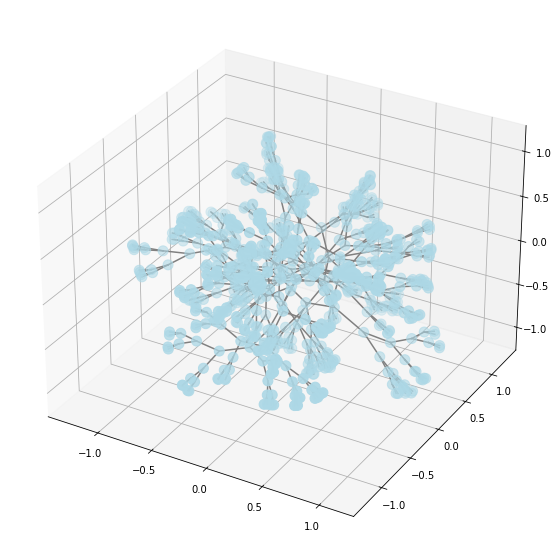

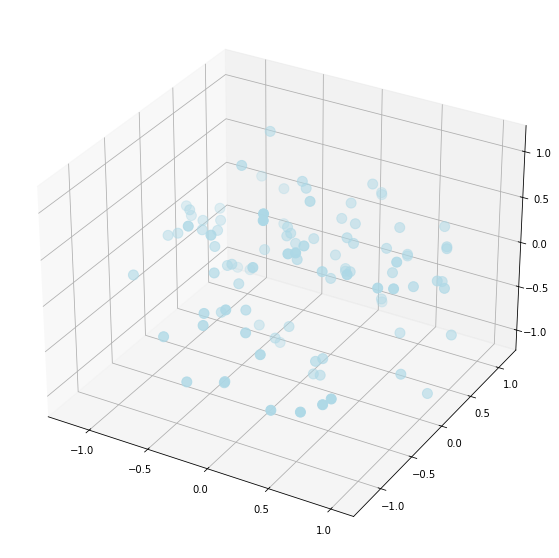

Generated a tree with 485 nodes for d=4 and depth=5


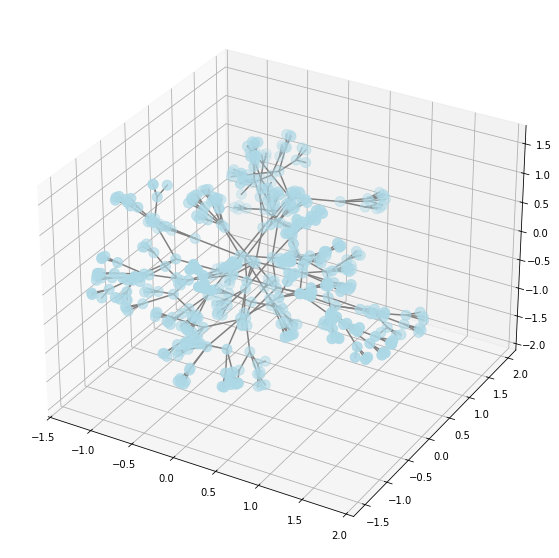

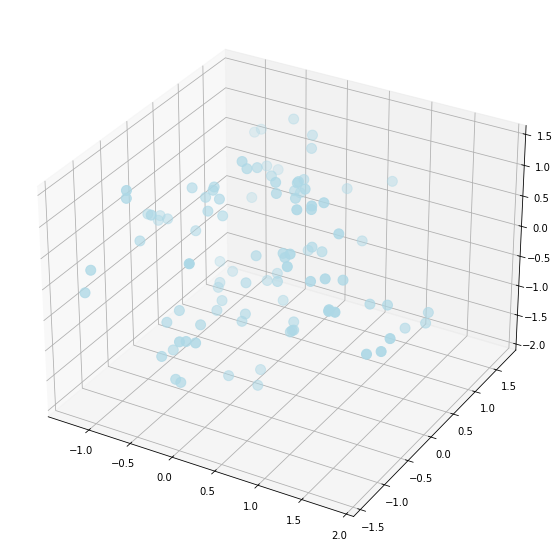

Generated a tree with 426 nodes for d=5 and depth=4


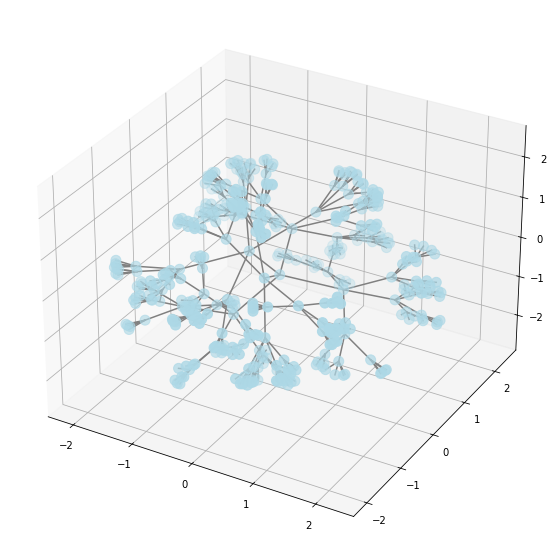

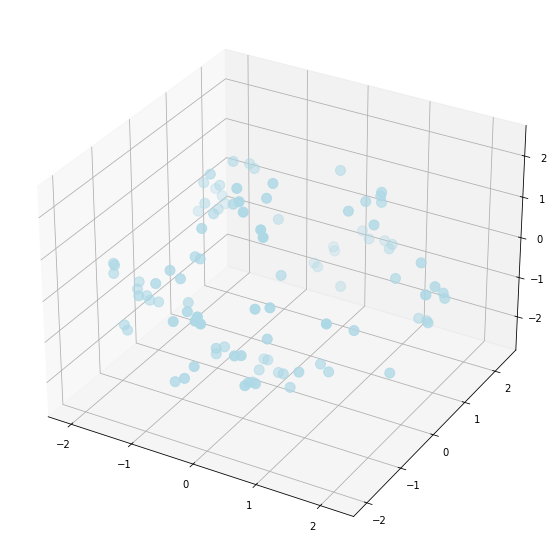

Generated a tree with 1706 nodes for d=5 and depth=5


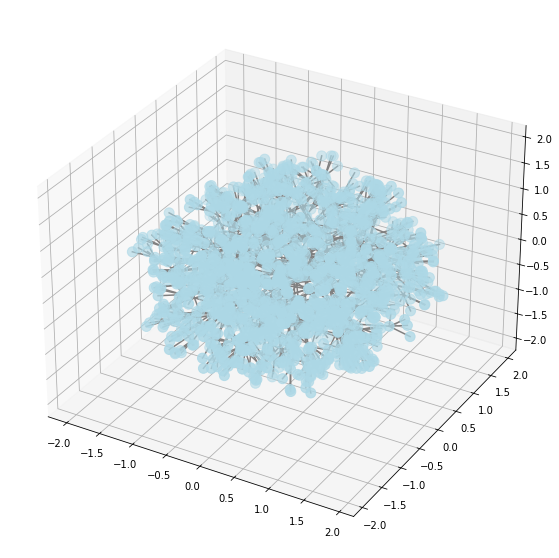

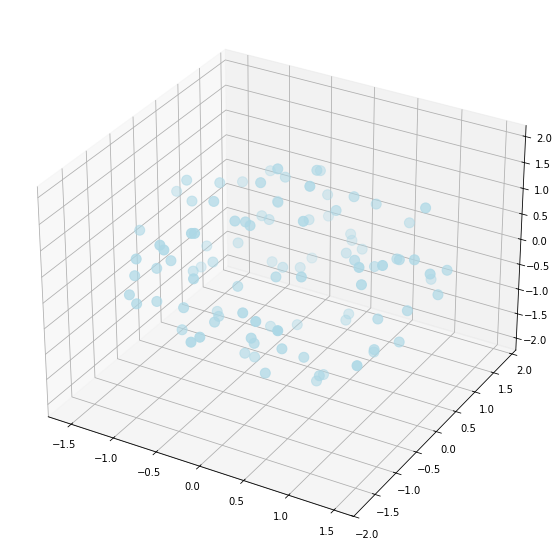

Generated a tree with 937 nodes for d=6 and depth=4


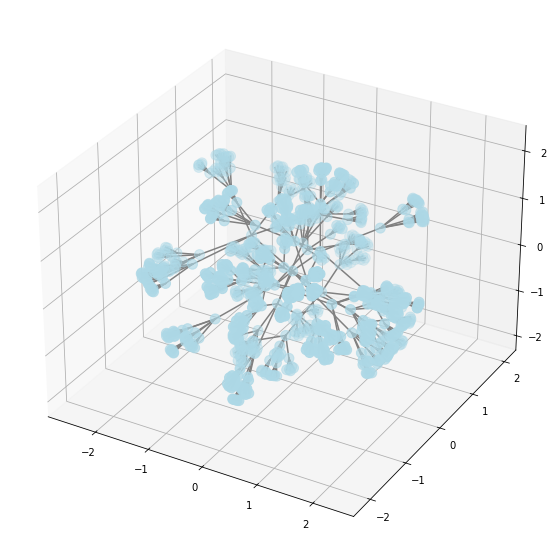

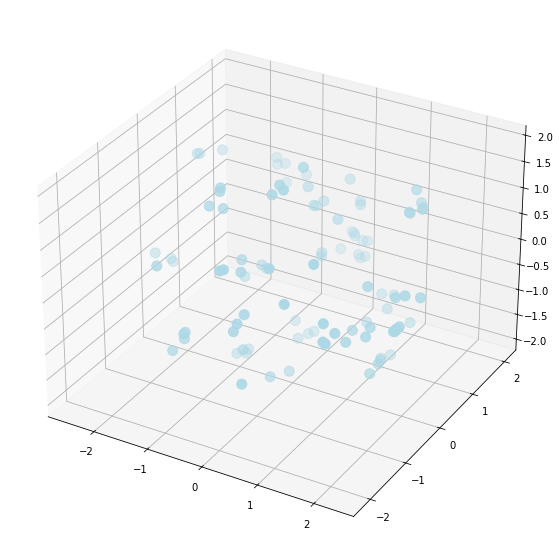

Generated a tree with 1814 nodes for d=7 and depth=4


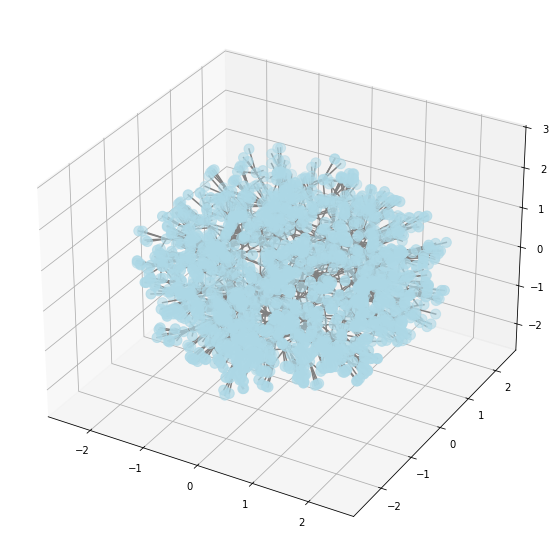

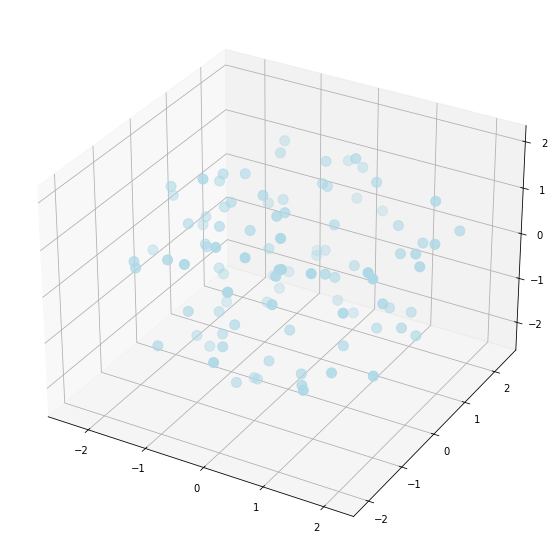

In [ ]:
from mpl_toolkits.mplot3d import Axes3D

for d, depth in combos:
    G = generate_regular_tree(d, depth)
    print(f"Generated a tree with {G.number_of_nodes()} nodes for d={d} and depth={depth}")
    k_perturb = np.random.uniform(0,0.1)
    depth_perturb = np.random.uniform(-0.1,0.1)

    pos = nx.spring_layout(G, dim=3, k = k_perturb, scale = 10/(depth*(1+depth_perturb))) # 3D layout for the graph

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    # Extract node positions
    x = [pos[node][0] for node in G.nodes()]
    y = [pos[node][1] for node in G.nodes()]
    z = [pos[node][2] for node in G.nodes()]

    # Plot nodes
    ax.scatter(x, y, z, c='lightblue', s=100)

    # Plot edges
    for edge in G.edges():
        x_coords = [pos[edge[0]][0], pos[edge[1]][0]]
        y_coords = [pos[edge[0]][1], pos[edge[1]][1]]
        z_coords = [pos[edge[0]][2], pos[edge[1]][2]]
        ax.plot(x_coords, y_coords, z_coords, c='gray')

    plt.show()

    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111, projection='3d')

    sampled_indices = np.random.choice(len(G.nodes()), size=100, replace=False)
    sampled_nodes = [list(G.nodes())[i] for i in sampled_indices]

    # Extract node positions
    x = [pos[node][0] for node in sampled_nodes]
    y = [pos[node][1] for node in sampled_nodes]
    z = [pos[node][2] for node in sampled_nodes]

    # Plot nodes
    ax.scatter(x, y, z, c='lightblue', s=100)

    # Plot edges
    for edge in G.edges():
        x_coords = [pos[edge[0]][0], pos[edge[1]][0]]
        y_coords = [pos[edge[0]][1], pos[edge[1]][1]]
        z_coords = [pos[edge[0]][2], pos[edge[1]][2]]

    plt.show()

